# 06. Your data: an ARIMA workflow template

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/06_your_data_template.ipynb)

**Use this notebook on your own time series.** It runs the whole workflow from the workshop: check the data, test stationarity, pick orders, fit, diagnose, backtest, and forecast. It ends with a methods paragraph that you can adapt for a paper or a dissertation chapter.

By default it runs on a **sample series** (monthly mean energy demand), so you can see how it works first. Then change the settings in the next cell and run it again.

**Privacy.** Do not upload sensitive or personal data to Colab or to any shared place. Use a local install for that data.

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def _read_energy(path):
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df


def load_energy():
    """Load the daily energy demand file. Local copy first, then GitHub, then an upload on Colab."""
    name = "energy_demand_daily.csv"
    for base in (Path("../data"), Path("data"), Path(".")):
        if (base / name).exists():
            return _read_energy(base / name)
    try:
        return _read_energy(RAW + name)
    except Exception as exc:
        if not IN_COLAB:
            raise
        print(f"The download failed ({type(exc).__name__}). Choose {name} from your computer or from Drive.")
        from google.colab import files
        files.upload()
        return _read_energy(Path(name))

In [2]:
from statsmodels.tsa.stattools import adfuller


def adf(series, label, regression="c"):
    """Run the Augmented Dickey-Fuller test and print a plain verdict."""
    stat, pvalue, lags, nobs, crit, _ = adfuller(series.dropna(), regression=regression, autolag="AIC")
    verdict = "reject the unit root (looks stationary)" if pvalue < 0.05 else "cannot reject the unit root (looks non-stationary)"
    print(f"{label:<28} ADF = {stat:7.2f}   p = {pvalue:.4f}   lags = {lags:<3} -> {verdict}")

## 1. Settings: change these for your data

In [3]:
DATA_PATH = None        # Path to your CSV, for example "my_data.csv". None runs the sample series.
DATE_COL = "date"       # Name of the date column.
VALUE_COL = "value"     # Name of the column to forecast.
FREQ = "MS"             # Pandas frequency: "D" day, "W-SUN" week, "MS" month start, "QS" quarter start, "YS" year start.
SEASON = 12             # Season length in observations: 12 for monthly, 7 for daily, 52 for weekly, 4 for quarterly. Use 1 for none.
HORIZON = 12            # How many steps ahead to forecast.
N_BACKTEST = 6          # Number of rolling origins for the backtest.

## 2. Load the data

On Colab, if your file is not found, the cell offers an upload dialog.

In [4]:
if DATA_PATH is None:
    sample = load_energy()["demand_gwh"].resample("MS").mean()
    raw = sample.rename("value").reset_index()
    DATE_COL, VALUE_COL = "date", "value"
    print("Using the sample series: monthly mean energy demand, 2015 to 2024.")
else:
    if not Path(DATA_PATH).exists() and IN_COLAB:
        from google.colab import files
        files.upload()
    raw = pd.read_csv(DATA_PATH)

series = (raw.assign(**{DATE_COL: pd.to_datetime(raw[DATE_COL])})
             .sort_values(DATE_COL).set_index(DATE_COL)[VALUE_COL].astype(float))
display(raw.head())

Using the sample series: monthly mean energy demand, 2015 to 2024.


,date,value
0,2015-01-01,1236.016774
1,2015-02-01,1233.761786
2,2015-03-01,1215.799355
3,2015-04-01,1196.778333
4,2015-05-01,1199.659677


## 3. Data checklist

This step catches the problems that break most student forecasts. Read every line of the output.

In [5]:
problems = []
n = len(series)
print(f"observations       : {n}")
print(f"range              : {series.index.min().date()} to {series.index.max().date()}")

dups = series.index.duplicated().sum()
print(f"duplicate dates    : {dups}")
if dups:
    problems.append("Duplicate dates. Aggregate or remove them first.")

full_index = pd.date_range(series.index.min(), series.index.max(), freq=FREQ)
missing_dates = full_index.difference(series.index)
print(f"missing dates      : {len(missing_dates)} (for frequency {FREQ})")
if len(missing_dates):
    problems.append("Missing dates. Decide how to fill them and report the method.")

nan_count = int(series.isna().sum())
print(f"missing values     : {nan_count}")
if nan_count:
    problems.append("Missing values. Interpolate or model them, and report the method.")

needed = max(50, 3 * SEASON)
print(f"enough history     : {n} observations, rule of thumb needs at least {needed}")
if n < needed:
    problems.append(f"Short series. Aim for at least {needed} observations, or use a simpler model.")

z = (series - series.rolling(max(5, SEASON), center=True, min_periods=3).median()).abs()
z = z / (1.4826 * z.median())
flagged = series[z > 6]
print(f"possible outliers  : {len(flagged)}")
if len(flagged):
    display(flagged.to_frame("flagged value"))

print()
print("Problems to fix before you continue:" if problems else "No blocking problems found.")
for item in problems:
    print(" -", item)

observations       : 120
range              : 2015-01-01 to 2024-12-01
duplicate dates    : 0
missing dates      : 0 (for frequency MS)
missing values     : 0
enough history     : 120 observations, rule of thumb needs at least 50
possible outliers  : 1


,flagged value
date,
2020-04-01,1292.512



No blocking problems found.


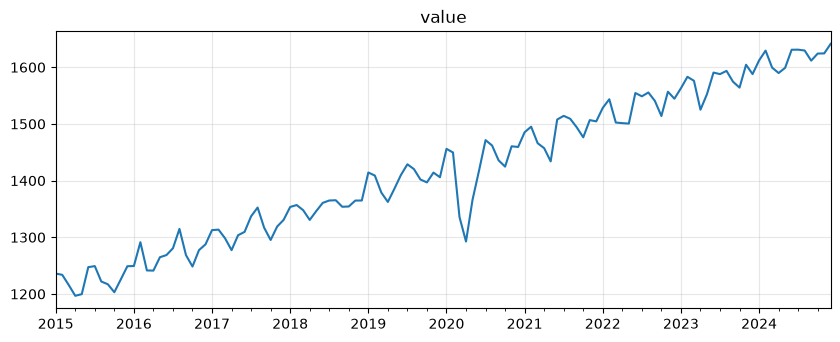

In [6]:
series = series.reindex(full_index).interpolate()      # simple repair so the notebook can continue. Document your own choice.
series.index.freq = FREQ
series.plot(title=f"{VALUE_COL}")
plt.show()

## 4. Stationarity and differencing

The cell raises $d$ until the ADF test passes, up to 2. It then checks whether a seasonal difference ($D = 1$) is useful, using the STL seasonal strength.

In [7]:
from statsmodels.tsa.seasonal import STL

work = series.copy()
for d in range(3):
    stat_p = adfuller(work.dropna(), autolag="AIC")[1]
    print(f"after {d} difference(s): ADF p = {stat_p:.4f}")
    if stat_p < 0.05 or d == 2:
        break
    work = work.diff()

if SEASON > 1 and len(series) >= 2 * SEASON:
    parts = STL(series, period=SEASON, robust=True).fit()
    strength = max(0.0, 1 - parts.resid.var() / (parts.seasonal + parts.resid).var())
    D = 1 if strength > 0.6 else 0
    print(f"seasonal strength = {strength:.2f} -> D = {D}")
else:
    strength, D = 0.0, 0
    print("No seasonal part (SEASON is 1 or the series is too short) -> D = 0")
print(f"Chosen: d = {d}, D = {D}")

after 0 difference(s): ADF p = 0.9334
after 1 difference(s): ADF p = 0.0000
seasonal strength = 0.53 -> D = 0
Chosen: d = 1, D = 0


## 5. Grid search by BIC

A small grid keeps the run fast and the report honest. State the grid in your methods section.

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

use_seasonal = SEASON > 1 and D == 1 and SEASON <= 24
if SEASON > 24:
    print("SEASON is above 24. SARIMA gets slow and unstable here.\n"
          "Consider Fourier terms as exogenous variables, or a coarser frequency. Fitting without a seasonal part.")

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p in range(3):
        for q in range(3):
            for P in (range(2) if use_seasonal else [0]):
                for Q in (range(2) if use_seasonal else [0]):
                    seasonal = (P, D, Q, SEASON) if use_seasonal else (0, 0, 0, 0)
                    try:
                        res = SARIMAX(series, order=(p, d, q), seasonal_order=seasonal).fit(disp=False, maxiter=200)
                        rows.append({"p": p, "q": q, "P": P, "Q": Q, "AIC": res.aic, "BIC": res.bic})
                    except Exception:
                        pass
grid = pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)
display(grid.head(5).round(1))
b = grid.iloc[0]
ORDER = (int(b.p), d, int(b.q))
SEASONAL = (int(b.P), D, int(b.Q), SEASON) if use_seasonal else (0, 0, 0, 0)
print("Chosen:", ORDER, SEASONAL)

,p,q,P,Q,AIC,BIC
0,2,2,0,0,1080.2,1094.1
1,2,1,0,0,1101.5,1112.6
2,0,2,0,0,1107.8,1116.1
3,1,2,0,0,1109.4,1120.5
4,2,0,0,0,1115.9,1124.2


Chosen: (2, 1, 2) (0, 0, 0, 0)


## 6. Fit and diagnose

Read the Ljung-Box p-values. A small value means the model left structure in the residuals. Go back to step 5, change the grid or the differencing, and try again.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9851      0.049     20.201      0.000       0.890       1.081
ar.L2         -0.9247      0.043    -21.306      0.000      -1.010      -0.840
ma.L1         -1.1149      0.078    -14.376      0.000      -1.267      -0.963
ma.L2          0.7838      0.078     10.000      0.000       0.630       0.937
sigma2       464.3050     45.317     10.246      0.000     375.485     553.125


,lb_stat,lb_pvalue
10,18.7911,0.0045
24,40.8552,0.0039
36,51.2885,0.0167


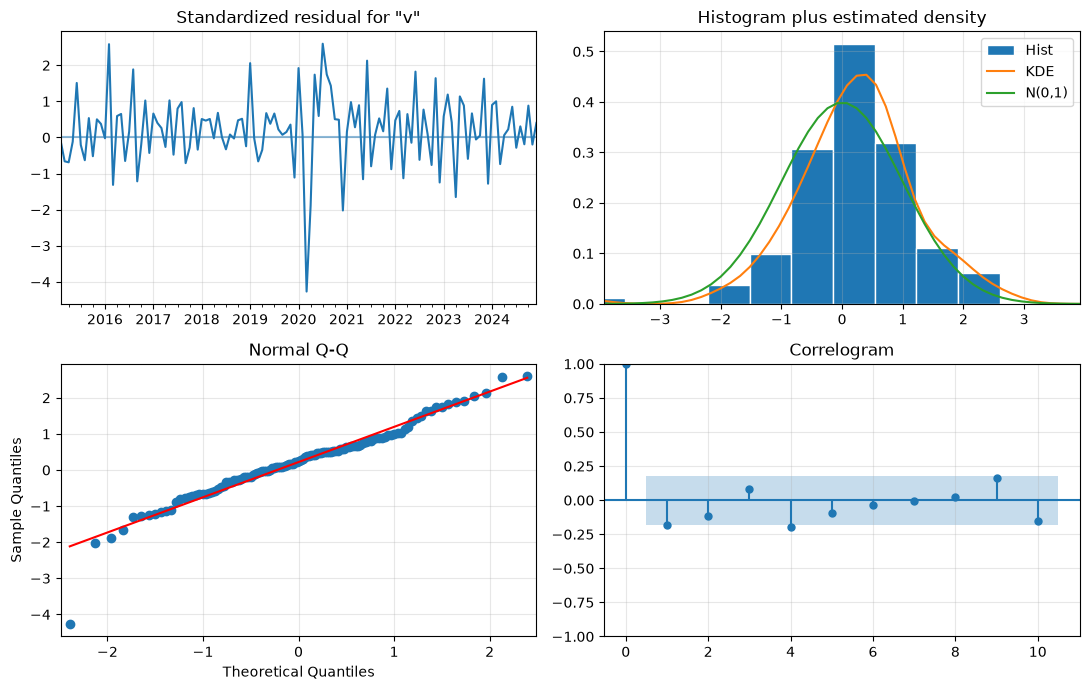

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

model = SARIMAX(series, order=ORDER, seasonal_order=SEASONAL).fit(disp=False, maxiter=200)
print(model.summary().tables[1])

skip = d + D * (SEASON if use_seasonal else 0)
resid = model.resid.iloc[skip:]
lags = [l for l in (10, 2 * max(SEASON, 1), 3 * max(SEASON, 1)) if l < len(resid) // 2]
display(acorr_ljungbox(resid, lags=lags, model_df=ORDER[0] + ORDER[2], return_df=True).round(4))
model.plot_diagnostics(figsize=(11, 7))
plt.tight_layout()
plt.show()

## 7. Rolling-origin backtest against a naive baseline

In [10]:
m = max(SEASON, 1)
H = min(HORIZON, max(1, len(series) // 10))
min_train = max(needed, len(series) - N_BACKTEST * H - H)
errors_model, errors_naive, truths = [], [], []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for k in range(N_BACKTEST):
        cut = min_train + k * H
        if cut + H > len(series):
            break
        hist, truth = series.iloc[:cut], series.iloc[cut:cut + H]
        f = SARIMAX(hist, order=ORDER, seasonal_order=SEASONAL).fit(disp=False, maxiter=200).forecast(H)
        naive = pd.Series([hist.iloc[len(hist) - m + (i % m)] if m > 1 else hist.iloc[-1] for i in range(H)], index=truth.index)
        errors_model.append((truth - f.values).values)
        errors_naive.append((truth - naive).values)
        truths.append(truth.values)

em, en, tt = map(np.concatenate, (errors_model, errors_naive, truths))
scale = (series - series.shift(m)).abs().mean() if m > 1 else series.diff().abs().mean()
table = pd.DataFrame({
    "model": {"MAE": np.abs(em).mean(), "RMSE": np.sqrt((em ** 2).mean()), "MASE": np.abs(em).mean() / scale},
    "naive baseline": {"MAE": np.abs(en).mean(), "RMSE": np.sqrt((en ** 2).mean()), "MASE": np.abs(en).mean() / scale},
}).round(2)
print(f"{len(errors_model)} origins, horizon {H}")
display(table)
verdict = "beats" if np.abs(em).mean() < np.abs(en).mean() else "does NOT beat"
print(f"The model {verdict} the naive baseline on this backtest.")

5 origins, horizon 12


,model,naive baseline
MAE,23.44,48.11
RMSE,31.13,53.17
MASE,0.51,1.04


The model beats the naive baseline on this backtest.


## 8. Forecast

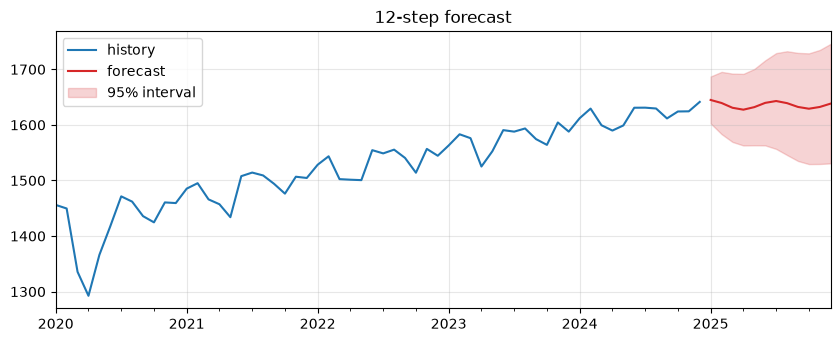

,forecast,lower_95,upper_95
2025-01-01,1644.9,1602.6,1687.1
2025-02-01,1639.4,1583.4,1695.4
2025-03-01,1630.8,1569.3,1692.3
2025-04-01,1627.4,1563.0,1691.8
2025-05-01,1632.0,1563.3,1700.6
2025-06-01,1639.6,1563.1,1716.2
2025-07-01,1643.0,1556.8,1729.1
2025-08-01,1639.1,1545.8,1732.5
2025-09-01,1632.3,1535.1,1729.5
2025-10-01,1629.1,1529.5,1728.7


In [11]:
fc = model.get_forecast(HORIZON)
mean, ci = fc.predicted_mean, fc.conf_int(alpha=0.05)

fig, ax = plt.subplots()
series.iloc[-max(60, 4 * HORIZON):].plot(ax=ax, label="history")
mean.plot(ax=ax, color="tab:red", label="forecast")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="tab:red", alpha=0.2, label="95% interval")
ax.legend()
ax.set_title(f"{HORIZON}-step forecast")
plt.show()

out = pd.concat([mean.rename("forecast"), ci], axis=1)
out.columns = ["forecast", "lower_95", "upper_95"]
display(out.round(1))

## 9. Methods paragraph

The cell fills in a paragraph from your own results. Edit it, and add the data source, the units, and the reason for each choice.

In [12]:
paragraph = (
    f"We modeled {VALUE_COL} ({n} observations, {series.index.min().date()} to {series.index.max().date()}) "
    f"with an {'seasonal ' if use_seasonal else ''}ARIMA{ORDER}{SEASONAL if use_seasonal else ''} model estimated by maximum likelihood in statsmodels. "
    f"The order of differencing was chosen with the Augmented Dickey-Fuller test (d = {d}, D = {D}). "
    f"The remaining orders came from a grid search that minimized the Bayesian information criterion. "
    f"We checked the residuals with the Ljung-Box test and residual plots. "
    f"We evaluated forecasts with a rolling-origin backtest of {len(errors_model)} origins and a horizon of {H} steps. "
    f"The model reached an MAE of {np.abs(em).mean():.2f} against {np.abs(en).mean():.2f} for a naive baseline. "
    f"Forecasts include 95% prediction intervals."
)
print(paragraph)

We modeled value (120 observations, 2015-01-01 to 2024-12-01) with an ARIMA(2, 1, 2) model estimated by maximum likelihood in statsmodels. The order of differencing was chosen with the Augmented Dickey-Fuller test (d = 1, D = 0). The remaining orders came from a grid search that minimized the Bayesian information criterion. We checked the residuals with the Ljung-Box test and residual plots. We evaluated forecasts with a rolling-origin backtest of 5 origins and a horizon of 12 steps. The model reached an MAE of 23.44 against 48.11 for a naive baseline. Forecasts include 95% prediction intervals.


## Checklist before you trust the result

- [ ] The data checklist found no unresolved problem.
- [ ] You explained any break or outlier in the series.
- [ ] The residual tests show no leftover structure, or you explained why you accept it.
- [ ] The model beats a simple baseline in a backtest.
- [ ] You report intervals and their coverage, not only point forecasts.
- [ ] You can reproduce every number from the code and the data.